# Function Edge Inferer

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import networkx as nx
import torch

from gsnn.models.GSNN import GSNN
from gsnn.simulate.nx2pyg import nx2pyg
from gsnn.simulate.simulate import simulate

from sklearn.metrics import roc_auc_score, roc_curve
from gsnn.optim.FunctionEdgeInferer import FunctionEdgeInferer

torch.manual_seed(0)
np.random.seed(0)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

%load_ext autoreload
%autoreload 2

## Build ground-truth graph and simulate data

In [2]:
def build_convergence_graph(n_tier_a=6):
    n = n_tier_a
    G = nx.DiGraph()
    func_func_edges_TRUE = []
    input_nodes = [f'in{i}' for i in range(n)]
    tier_a = [f'f{i}' for i in range(n)]
    tier_b = [f'f{n + k}' for k in range(n - 1)]
    tier_c = [f'f{2 * n - 1}']
    function_nodes = tier_a + tier_b + tier_c
    output_nodes = [f'o{k}' for k in range(n)]
    for i, u in enumerate(input_nodes):
        G.add_edge(u, tier_a[i])
    for k in range(n - 1):
        b = tier_b[k]
        for parent in (tier_a[k], tier_a[k + 1]):
            G.add_edge(parent, b)
            func_func_edges_TRUE.append((parent, b))
    sink = tier_c[0]
    for b in tier_b:
        G.add_edge(b, sink)
        func_func_edges_TRUE.append((b, sink))
    for k, b in enumerate(tier_b):
        G.add_edge(b, output_nodes[k])
    G.add_edge(sink, output_nodes[n - 1])
    return G, input_nodes, function_nodes, output_nodes, func_func_edges_TRUE

def default_held_out_edges(n_tier_a, b2sink_stride=2):
    n = n_tier_a
    sink = f'f{2 * n - 1}'
    held = [(f'f{k}', f'f{n + k}') for k in range(1, n - 1)]
    held += [(f'f{n + k}', sink) for k in range(0, n - 1, b2sink_stride)]
    return held

N_TIER_A = 25
G, input_nodes, function_nodes, output_nodes, func_func_edges_TRUE = build_convergence_graph(N_TIER_A)
N_FUNC = len(function_nodes)
HELD_OUT_EDGES = default_held_out_edges(N_TIER_A)

x_train, x_test, y_train, y_test = simulate(
    G, n_train=1000, n_test=500,
    input_nodes=input_nodes, output_nodes=output_nodes,
    noise_scale=0.25, special_functions=None,
)
x_train = torch.tensor(x_train, dtype=torch.float32).to(device)
x_test = torch.tensor(x_test, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).to(device)
y_mu, y_std = y_train.mean(0), y_train.std(0)
y_train = (y_train - y_mu) / (y_std + 1e-8)
y_test = (y_test - y_mu) / (y_std + 1e-8)

held_out_set = set(HELD_OUT_EDGES)
G_partial = G.copy()
G_partial.remove_edges_from(HELD_OUT_EDGES)
data = nx2pyg(G_partial, input_nodes, function_nodes, output_nodes)
kept_edges = [e for e in func_func_edges_TRUE if e not in held_out_set]
kept_ff_set = set(kept_edges)

sink = f'f{2 * N_TIER_A - 1}'
left_merge = [e for e in HELD_OUT_EDGES if e[1] != sink]
b2sink = [e for e in HELD_OUT_EDGES if e[1] == sink]
rng = np.random.default_rng(0)
rng.shuffle(left_merge); rng.shuffle(b2sink)
edges_val = left_merge[:len(left_merge)//2] + b2sink[:len(b2sink)//2]
edges_test = left_merge[len(left_merge)//2:] + b2sink[len(b2sink)//2:]
held_out_benchmark = set(edges_val) | set(edges_test)

print(f'functions: {N_FUNC} | held-out val/test: {len(edges_val)}/{len(edges_test)}')

functions: 50 | held-out val/test: 17/18


In [3]:
node_names = data.node_names_dict['function']

edge_index_val = torch.stack((torch.tensor([node_names.index(e[0]) for e in edges_val]),
                              torch.tensor([node_names.index(e[1]) for e in edges_val])),
                              dim=0)

edge_index_test = torch.stack((torch.tensor([node_names.index(e[0]) for e in edges_test]),
                              torch.tensor([node_names.index(e[1]) for e in edges_test])),
                              dim=0)

print('n val edges', edge_index_val.shape[1])
print('n test edges', edge_index_test.shape[1])

from gsnn.optim.FunctionEdgeInferer import mrr

def report(model, crit): 
        
    FEI = FunctionEdgeInferer(model, crit, edge_index=data.edge_index_dict['function','to','function'], 
                            use_prenorm=True, device='cpu', norm='l1', agg='sum')
    W = FEI.fit(x_test, y_test, method='spearman', penalty_factor=0.0, scale_by_act_mean=False,
                bootstrap=False, bootstrap_iters=1) 

    all_true_edges = torch.cat((data.edge_index_dict['function','to','function'], 
                                edge_index_val, edge_index_test), dim=1)
    val_mrr = mrr(torch.tensor(W), edge_index_val, all_true_edges)
    test_mrr = mrr(torch.tensor(W), edge_index_test, all_true_edges)
    random_mrr = mrr(torch.rand(W.shape), edge_index_val, all_true_edges)

    return val_mrr, test_mrr, random_mrr

n val edges 17
n test edges 18


## Train GSNN

epoch  1 | test MSE 1.0245 | val MRR 0.6471 | test MRR 0.6423 | random MRR 0.1189
epoch  2 | test MSE 1.0162 | val MRR 0.6769 | test MRR 0.6496 | random MRR 0.0975
epoch  3 | test MSE 1.0031 | val MRR 0.6810 | test MRR 0.6656 | random MRR 0.1161
epoch  4 | test MSE 0.9831 | val MRR 0.6917 | test MRR 0.6879 | random MRR 0.0764
epoch  5 | test MSE 0.9549 | val MRR 0.7013 | test MRR 0.7006 | random MRR 0.1232
epoch  6 | test MSE 0.9163 | val MRR 0.7250 | test MRR 0.7292 | random MRR 0.0841
epoch  7 | test MSE 0.8654 | val MRR 0.7814 | test MRR 0.8148 | random MRR 0.0811
epoch  8 | test MSE 0.8024 | val MRR 0.9118 | test MRR 0.8796 | random MRR 0.1048
epoch  9 | test MSE 0.7303 | val MRR 0.9706 | test MRR 0.8796 | random MRR 0.0676
epoch 10 | test MSE 0.6591 | val MRR 0.9412 | test MRR 0.8889 | random MRR 0.1052
epoch 11 | test MSE 0.6016 | val MRR 0.9412 | test MRR 0.9167 | random MRR 0.0777
epoch 12 | test MSE 0.5694 | val MRR 0.9706 | test MRR 0.9167 | random MRR 0.0809
epoch 13 | test 

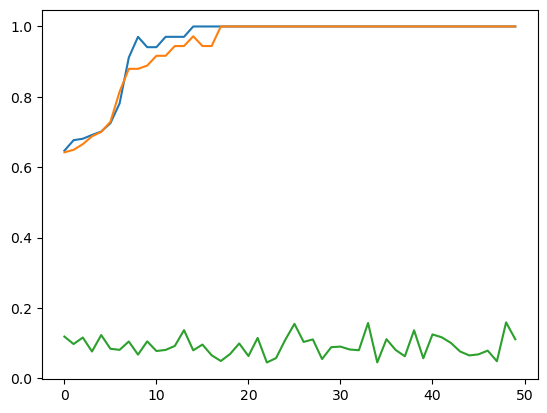

In [14]:
BATCH_SIZE = 128

model_kwargs = dict(
    channels=10, layers=6, share_layers=False, bias=True,
    add_function_self_edges=True, norm='none', dropout=0.2,
    nonlin=torch.nn.ELU, node_mlp=False, checkpoint=False,
)

model = GSNN(data.edge_index_dict, data.node_names_dict, **model_kwargs).to(device)

train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(x_train, y_train),
    batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
)
infer_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(x_train, y_train),
    batch_size=BATCH_SIZE, shuffle=False, drop_last=True,
)
gsnn_optim = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0)
crit = torch.nn.MSELoss()

n_epochs = 50
val_mrrs = []; test_mrrs = []; random_mrrs = []
for epoch in range(n_epochs):
    model.train()
    for x_batch, y_batch in train_loader:
        gsnn_optim.zero_grad()
        loss = crit(model(x_batch), y_batch)
        loss.backward()
        gsnn_optim.step()
    if epoch == 0 or (epoch + 1) % 1 == 0 or epoch == n_epochs - 1:
        model.eval()
        with torch.no_grad():
            mse = crit(model(x_test), y_test).item()

        val_mrr, test_mrr, random_mrr = report(model, crit)
        val_mrrs.append(val_mrr); test_mrrs.append(test_mrr); random_mrrs.append(random_mrr)
        print(f'epoch {epoch+1:2d} | test MSE {mse:.4f} | val MRR {val_mrr:.4f} | test MRR {test_mrr:.4f} | random MRR {random_mrr:.4f}')


plt.figure()
plt.plot(val_mrrs)
plt.plot(test_mrrs)
plt.plot(random_mrrs)
plt.show()


In [61]:
from gsnn.optim.FunctionEdgeInferer import _get_node_attrs 
a,g = _get_node_attrs(model=model, crit=crit, x=x_train, y=y_train)

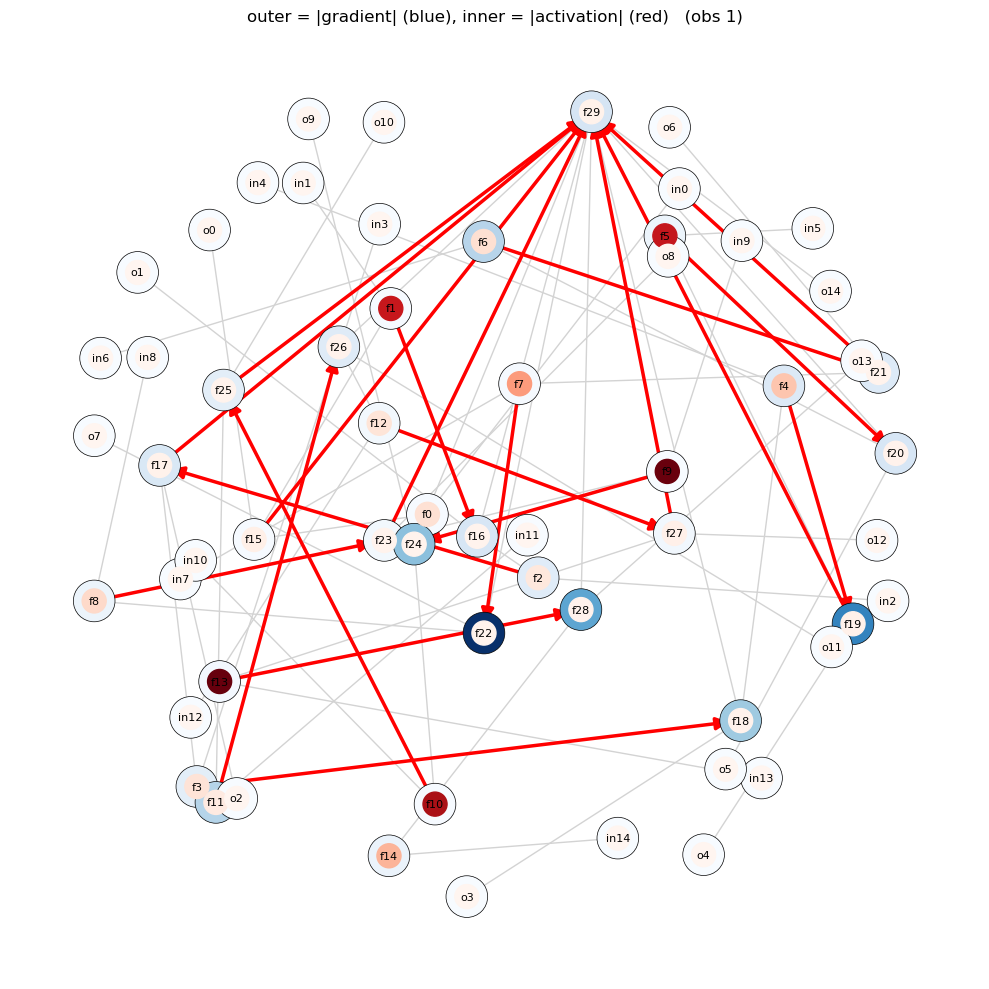

In [63]:
obs_idx = 1

a_obs = a[obs_idx]  # (N_func,)
g_obs = g[obs_idx]   # (N_func,)

name2idx = {n: i for i, n in enumerate(node_names)}
def node_values(vec):
    return [vec[name2idx[n]] if n in name2idx else 0.0 for n in G.nodes()]

pos = nx.spring_layout(G, k=1, seed=0)

fig, ax = plt.subplots(figsize=(10, 10))

nx.draw_networkx_edges(G, pos=pos, ax=ax, edge_color='lightgray')
nx.draw_networkx_edges(
    G, pos=pos, ax=ax,
    edgelist=HELD_OUT_EDGES,
    edge_color='red', width=2.5, arrowsize=18,
)

outer_size, inner_size = 900, 300
nodelist = list(G.nodes())

nx.draw_networkx_nodes(
    G, pos=pos, ax=ax, nodelist=nodelist,
    node_color=node_values(g_obs), cmap='Blues', vmin=0,
    node_size=outer_size, edgecolors='black', linewidths=0.5,
)
nx.draw_networkx_nodes(
    G, pos=pos, ax=ax, nodelist=nodelist,
    node_color=node_values(a_obs), cmap='Reds', vmin=0,
    node_size=inner_size,
)
nx.draw_networkx_labels(G, pos=pos, ax=ax, font_size=8)

ax.set_title(f'outer = |gradient| (blue), inner = |activation| (red)   (obs {obs_idx})')
ax.axis('off')

plt.tight_layout()
plt.show()



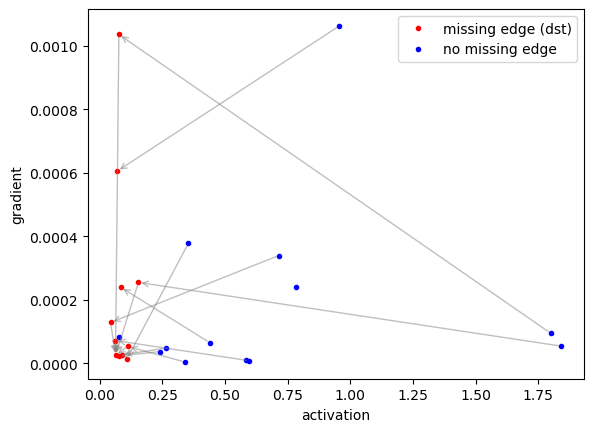

In [151]:
# Nodes that are missing an edge typically have low activation and high gradient

node_names = data.node_names_dict['function']
nodes_missing_an_edge = [node_names.index(dst) for src, dst in HELD_OUT_EDGES]
M = torch.zeros(N)
M[nodes_missing_an_edge] = 1

obs_idx = 1
a_obs = a[obs_idx].detach().cpu().numpy()   # (N_func,)
g_obs = g[obs_idx].detach().cpu().numpy()   # (N_func,)

fig, ax = plt.subplots()
ax.plot(a_obs[M == 1], g_obs[M == 1], 'r.', label='missing edge (dst)')
ax.plot(a_obs[M == 0], g_obs[M == 0], 'b.', label='no missing edge')

for src_name, dst_name in HELD_OUT_EDGES:
    i = node_names.index(src_name)
    j = node_names.index(dst_name)
    ax.annotate(
        '', xy=(a_obs[j], g_obs[j]), xytext=(a_obs[i], g_obs[i]),
        arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5, lw=1),
    )

ax.set_xlabel('activation')
ax.set_ylabel('gradient')
ax.legend()
plt.show()

In [149]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

a_np = a.detach().cpu().numpy()                                # (B, N)
g_np = g.detach().cpu().numpy()                                # (B, N)
M_np = M.numpy()                                               # (N,)
B, N_nodes = a_np.shape

y = np.broadcast_to(M_np, (B, N_nodes)).reshape(-1)            # (B*N,)
x = np.stack([a_np.reshape(-1), g_np.reshape(-1)], axis=1)     # (B*N, 2)

clf = LogisticRegression(penalty=None, max_iter=1000)
clf.fit(x, y)

w_act, w_grad = clf.coef_[0]
print(f'classes:        {clf.classes_.tolist()}')
print(f'intercept:      {clf.intercept_[0]:+.4f}')
print(f'weight act:     {w_act:+.4f}')
print(f'weight grad:    {w_grad:+.4f}')
print(f'train accuracy: {clf.score(x, y):.4f}')
print(f'train ROC AUC:  {roc_auc_score(y, clf.predict_proba(x)[:, 1]):.4f}')


classes:        [0.0, 1.0]
intercept:      +0.2804
weight act:     -0.6189
weight grad:    +0.0013
train accuracy: 0.5985
train ROC AUC:  0.6265


/home/exacloud/gscratch/mcweeney_lab/evans/external/miniforge3/envs/gsnn/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


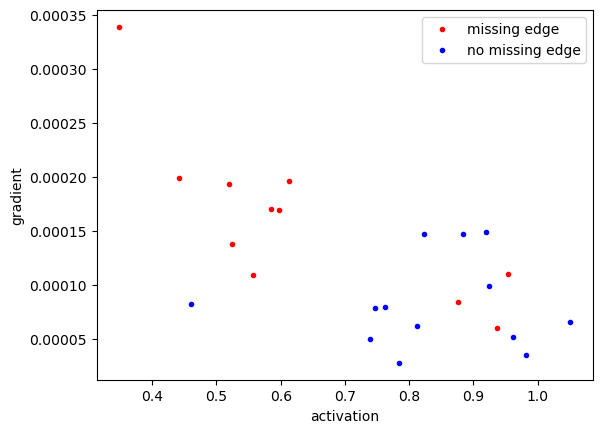

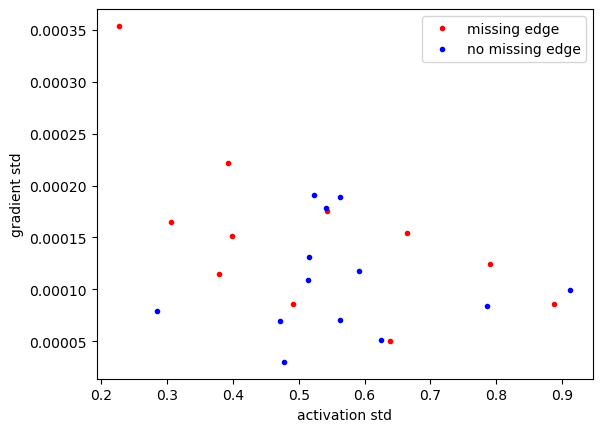

In [165]:
A_mean = a.mean(0)
G_mean = g.mean(0)

A_std = a.std(0)
G_std = g.std(0)

plt.figure()
plt.plot(A_mean[M==1], G_mean[M==1], 'r.', label='missing edge')
plt.plot(A_mean[M==0], G_mean[M==0], 'b.', label='no missing edge')
plt.xlabel('activation')
plt.ylabel('gradient')
plt.legend()
plt.show()

plt.figure()
plt.plot(A_std[M==1], G_std[M==1], 'r.', label='missing edge')
plt.plot(A_std[M==0], G_std[M==0], 'b.', label='no missing edge')
plt.xlabel('activation std')
plt.ylabel('gradient std')
plt.legend()
plt.show()
